In [1]:
from utils import *
import pandas as pd
import glob, os
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

In [2]:
dfs = []
for file in glob.glob("../results/experiment_solvers*d2*f11*.csv"):
    dfs.append(pd.read_csv(file))
    print(file)
df = pd.concat(dfs, ignore_index=True)

../results/experiment_solverslu_d2_p1_f11_mixed.csv
../results/experiment_solverscudss_d2_p1_f11_cubical.csv
../results/experiment_solverscholesky_d2_p1_f11_cubical.csv
../results/experiment_solversinv_d2_p1_f11_mixed.csv
../results/experiment_solvers_d2_p1_f11_simplicial.csv
../results/experiment_solverslu_d2_p1_f11_cubical.csv
../results/experiment_solversinv_d2_p1_f11_cubical.csv
../results/experiment_solverscudss_d2_p1_f11_mixed.csv
../results/experiment_solverscholesky_d2_p1_f11_mixed.csv
../results/experiment_solverscudss_ii_d2_p1_f11_cubical.csv
../results/experiment_solversinv16_d2_p1_f11_mixed.csv
../results/experiment_solversinv16_d2_p1_f11_cubical.csv
../results/experiment_solversinv-inv16-lu-cholesky_d2_p1_f11_cubical.csv
../results/experiment_solverscudss_ii_d2_p1_f11_mixed.csv


In [3]:
def nice_solver_name(solver: str):
    if "Inv(torch.float16)" in solver:
        return "Inv (fp16)"
    dense_solvers = ["LU", "Inv", "Cholesky"]
    for ds in dense_solvers:
        if ds in solver:
            return ds
    return "BatchCUDSS"


def process_experiments_df(df: pd.DataFrame):
    if "solve time" not in df.columns:
        return pd.DataFrame()

    df = df.copy()
    metadata_df = df.apply(extract_row_metadata, axis=1)
    metadata_cols = metadata_df.columns.tolist()
    df = pd.concat([df, metadata_df], axis=1)

    df["solver"] = df["solver"].apply(nice_solver_name)
    df[["coarse m", "solvers m", "fine m"]] = df.apply(get_meshes, axis=1)

    return df.pivot_table(
        index=["coarse m", "solvers m", "fine m"],
        columns=["solver"],
        values=metadata_cols,
        aggfunc="min",
    )

In [4]:
summary = process_experiments_df(df)
summary

asm setup time                              \
solver                         BatchCUDSS      Cholesky           Inv   
coarse m solvers m fine m                                               
(8, C)   (8, C)    (11, S)   21744.796875           NaN           NaN   
         (8, S)    (11, S)   28461.279297  11508.853516   4233.833496   
         (9, C)    (11, S)   60126.101562   9334.332031   2847.872070   
         (9, S)    (11, S)  129139.210938   8864.441406   1973.678101   
         (10, C)   (11, S)  110418.164062   8898.319336   1654.961182   
         (10, S)   (11, S)  774808.500000  12533.942383   1345.208374   
         (11, C)   (11, S)            NaN  15144.702148   1348.687866   
         (11, S)   (11, S)            NaN  31684.816406   1209.945068   
(8, S)   (8, S)    (11, S)   28879.808594  11979.477539           NaN   
         (9, S)    (11, S)  142876.078125   8385.157227   2643.087402   
         (10, S)   (11, S)  871522.750000  10405.283203   1945.942017   
         (11, S)   (11, S)            NaN  23583.183594   1954.956299   
(9, C)   (9, C)    (11, S)   59555.164062   9654.452148   3328.479248   
         (9, S)    (11, S)  162110.546875   9004.164062   2482.003906   
         (10, C)   (11, S)  111062.859375   9556.196289   2017.259521   
         (10, S)   (11, S)  953115.125000  12419.932617   1854.508057   
         (11, C)   (11, S)            NaN  19084.035156   1772.625977   
         (11, S)   (11, S)            NaN  30608.121094   1707.528198   
(9, S)   (9, S)    (11, S)  144161.734375   9649.270508   3884.456055   
         (10, S)   (11, S)  875354.437500  12082.941406   3332.423584   
         (11, S)   (11, S)            NaN  24718.335938   3177.188232   
(10, C)  (10, C)   (11, S)  113188.179688  11582.575195   3562.544189   
         (10, S)   (11, S)  956563.312500  14115.237305   3382.572021   
         (11, C)   (11, S)            NaN  23764.953125   3305.419678   
         (11, S)   (11, S)            NaN  31782.748047   3268.547607   
(10, S)  (10, S)   (11, S)  876020.937500  15815.911133   6361.037598   
         (11, S)   (11, S)            NaN  28018.949219   6355.224609   
(11, C)  (11, C)   (11, S)            NaN  29620.812500   9539.692383   
         (11, S)   (11, S)            NaN  38269.718750   9456.311523   
(11, S)  (11, S)   (11, S)            NaN  40285.621094  18142.753906   

                                                         asm time              \
solver                        Inv (fp16)            LU BatchCUDSS    Cholesky   
coarse m solvers m fine m                                                       
(8, C)   (8, C)    (11, S)           NaN  10176.261719  43.921921         NaN   
         (8, S)    (11, S)   3433.562012   7158.382812  44.625305   57.692468   
         (9, C)    (11, S)   2376.666016   5503.858887  42.090189   44.759961   
         (9, S)    (11, S)   1718.057983   4179.297363  43.900723   40.833023   
         (10, C)   (11, S)   1486.385132   2621.704102  41.522995   40.206644   
         (10, S)   (11, S)   1240.901611   2172.559326  74.198016   59.721625   
         (11, C)   (11, S)   1311.931396   2359.717773        NaN   73.244470   
         (11, S)   (11, S)   1168.257080   1751.988281        NaN  161.938843   
(8, S)   (8, S)    (11, S)           NaN   7777.321777  44.485120   56.720483   
         (9, S)    (11, S)   2444.353516   4786.625488  43.581952   38.303131   
         (10, S)   (11, S)   1898.801147   2815.048584  72.386768   49.289932   
         (11, S)   (11, S)   2058.923096   2642.793457        NaN  119.649695   
(9, C)   (9, C)    (11, S)   2845.714355   6310.180664  43.123508   45.846732   
         (9, S)    (11, S)   2209.045410   4655.238281  44.202905   42.734183   
         (10, C)   (11, S)   1916.306396   3077.795898  42.430875   43.650867   
         (10, S)   (11, S)   1716.343750   2707.342285  73.552283   61.709723   
         (11, C)   (11, S)   1778.622437   2729.151367        NaN   89.239862 

In [5]:
def get_plot_df(coarse_m: int, solver: str):
    data = (
        summary.xs(coarse_m, level="coarse m")
        .xs(solver, level="solver", axis=1)
        .reset_index()
        .set_index("solvers m")
    )
    total_local_solvers = "local solvers"
    total_coarse_solver = "coarse solver"
    total_asm_rest = "other ASM components"
    total_not_asm = "outer PCG"
    data[total_local_solvers] = data["local solvers time"] * data["iterations"]
    data[total_coarse_solver] = data["coarse solver time"] * data["iterations"]
    data[total_asm_rest] = (
        data["asm time"] - data["local solvers time"] - data["coarse solver time"]
    ) * data["iterations"]
    data[total_not_asm] = (
        data["cg time"]
        - data[total_asm_rest]
        - data[total_coarse_solver]
        - data[total_local_solvers]
    )
    to_plot = (
        data[[total_not_asm, total_asm_rest, total_coarse_solver, total_local_solvers]]
        / 1000
    )
    to_plot.sort_index(inplace=True)
    to_plot.rename(index=lambda s: f"${format_mesh(s)}$", inplace=True)
    return to_plot

In [6]:
coarse_meshes = summary.index.get_level_values("coarse m").unique().tolist()
coarse_meshes

[(8, 'C'),
 (8, 'S'),
 (9, 'C'),
 (9, 'S'),
 (10, 'C'),
 (10, 'S'),
 (11, 'C'),
 (11, 'S')]

In [7]:
solvers = summary.columns.get_level_values("solver").unique().tolist()
solvers

['BatchCUDSS', 'Cholesky', 'Inv', 'Inv (fp16)', 'LU']

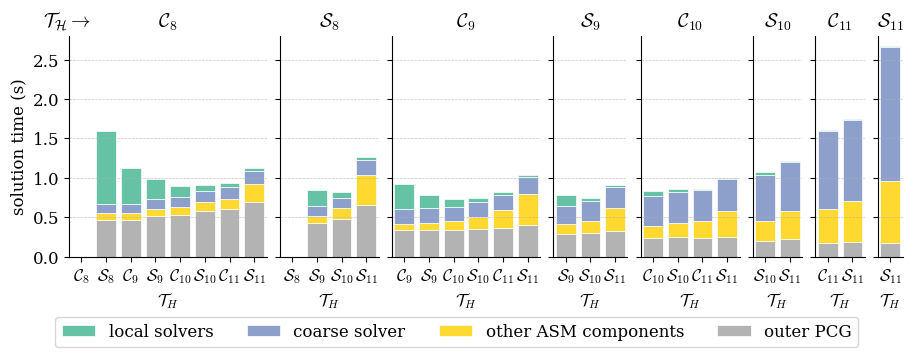

In [13]:
width_ratios = [
    len(summary.xs(cm, level="coarse m").index.get_level_values("solvers m").unique())
    for cm in coarse_meshes
]
fig, axes = plt.subplots(
    1,
    len(coarse_meshes),
    figsize=(9, 3),
    layout="constrained",
    sharey="row",
    width_ratios=width_ratios,
)
linthresh = 1
for ax, coarse_m in zip(axes.flat, coarse_meshes):
    plot_clustered_stacked(
        ax,
        [get_plot_df(coarse_m, solver) for solver in ["Inv (fp16)"]],
        solvers,
        add_legend=False,
    )
    ax.set_title(f"${format_mesh(coarse_m)}$")
    ax.set_xlabel("$\\mathcal{{T}}_H$")
    if coarse_m == (8, "C"):
        ax.set_ylabel("solution time (s)")

handles, labels = ax.get_legend_handles_labels()
fig.legend(
    handles[::-1],
    labels[::-1],
    loc="upper center",
    bbox_to_anchor=(0.5, -0.0),
    ncols=4,
)
fig.text(0.04, 0.94, "$\\mathcal{T}_\\mathcal{H}\\rightarrow$", fontsize=14)

fig.savefig("../docs/defence-media/inv_plots.svg", bbox_inches="tight")

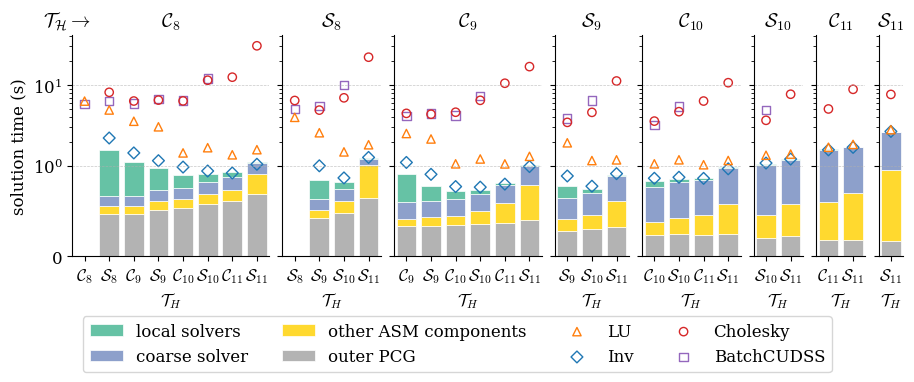

In [10]:
width_ratios = [
    len(summary.xs(cm, level="coarse m").index.get_level_values("solvers m").unique())
    for cm in coarse_meshes
]
fig, axes = plt.subplots(
    1,
    len(coarse_meshes),
    figsize=(9, 3),
    layout="constrained",
    sharey="row",
    width_ratios=width_ratios,
)
markers = {"Inv": "D", "LU": "^", "Cholesky": "o", "BatchCUDSS": "s", "Inv (fp16)": "P"}
solver_colors = {
    "Inv (fp16)": plt.cm.Set2(0),
    "LU": "#ff7f0e",
    "Inv": "#1f77b4",
    "Cholesky": "#d62728",
    "BatchCUDSS": "#9467bd",
}
linthresh = 1
for ax, coarse_m in zip(axes.flat, coarse_meshes):
    plot_clustered_stacked(
        ax,
        [get_plot_df(coarse_m, solver) for solver in ["Inv (fp16)"]],
        solvers,
        add_legend=False,
    )
    idx = 0
    for solver in solvers:
        if solver not in ["Inv (fp16)"]:
            df = get_plot_df(coarse_m, solver)
            non_nans = [i for i in range(len(df)) if df.notna().all(axis=1).iloc[i]]
            ax.scatter(
                non_nans,
                df.iloc[non_nans].sum(axis=1),
                label=solver,
                marker=markers[solver],
                facecolors="none",
                edgecolors=solver_colors.get(solver, "black"),
            )
            idx += 1
    # ax.set_title(f"$\\mathcal{{T}}_\\mathcal{{H}}={format_mesh(coarse_m)}$")
    ax.set_title(f"${format_mesh(coarse_m)}$")
    ax.set_xlabel("$\\mathcal{{T}}_H$")
    if coarse_m == (8, "C"):
        ax.set_ylabel("solution time (s)")
    # ax.tick_params(axis="yaxis", which="major", labelsize=10)
    # ax.tick_params(axis="both", which="minor", labelsize=8)
    ax.set_yscale("symlog", linthresh=linthresh)
    maj = ticker.SymmetricalLogLocator(linthresh=linthresh, base=10)
    # Minor ticks: 1..9 inside each decade (makes 2..9 visible between decades)
    minr = ticker.SymmetricalLogLocator(
        linthresh=linthresh, subs=np.arange(1, 10), base=10
    )
    ax.yaxis.set_major_locator(maj)
    ax.yaxis.set_minor_locator(minr)
    # Use a log-friendly formatter; labelOnlyBase=False lets some minor labels appear if desired
    ax.yaxis.set_major_formatter(
        ticker.LogFormatterMathtext(base=10, labelOnlyBase=False)
    )

handles, labels = ax.get_legend_handles_labels()
fig.legend(
    handles[::-1],
    labels[::-1],
    loc="upper center",
    bbox_to_anchor=(0.5, -0.0),
    ncols=4,
)
fig.text(0.04, 0.94, "$\\mathcal{T}_\\mathcal{H}\\rightarrow$", fontsize=14)

fig.savefig("../docs/thesis-media/solver_plots.svg", bbox_inches="tight")

## Setup times

In [10]:
local_solvers_setup_times = summary.pivot_table(
    index=["solvers m"], values=["local solvers setup time"]
)
local_solvers_setup_times

local solvers setup time                                        \
solver                  BatchCUDSS    Cholesky          Inv   Inv (fp16)   
solvers m                                                                  
(8, C)                12804.257812         NaN          NaN          NaN   
(8, S)                19409.955078  521.582382  1176.640747  1249.610718   
(9, C)                50718.095703  338.186768   751.644745   750.582764   
(9, S)               139494.822917  331.476070   523.660347   532.397316   
(10, C)              102163.497396  250.776962   269.160304   271.037776   
(10, S)              889910.350000  282.868055   293.810717   286.481415   
(11, C)                        NaN  191.802757   171.415943   173.299715   
(11, S)                        NaN  245.400814   229.800128   247.688061   

                       
solver             LU  
solvers m              
(8, C)     821.001160  
(8, S)     528.953201  
(9, C)     406.760941  
(9, S)     310.415001  
(10, C)    333.199707  
(10, S)    267.457397  
(11, C)    293.605762  
(11, S)    226.914261

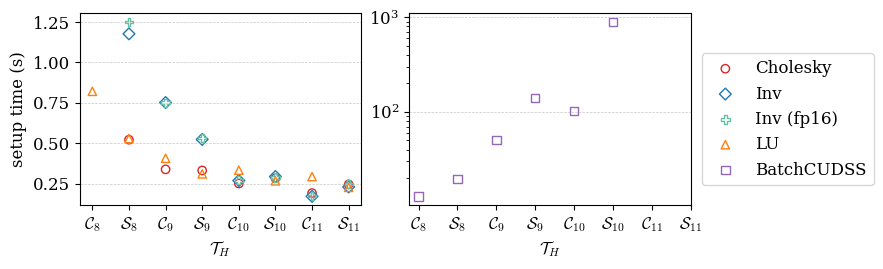

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(7, 2.5), layout="constrained")
for solver in solvers:
    ax = axes[1] if solver == "BatchCUDSS" else axes[0]
    data = local_solvers_setup_times.xs(solver, level="solver", axis=1) / 1000
    ax.scatter(
        range(len(data)),
        data.values,
        label=solver,
        marker=markers[solver],
        color=solver_colors.get(solver, "black"),
        facecolors="none",
    )
for i, ax in enumerate(axes):
    ax.yaxis.grid(True, linestyle="--", linewidth=0.5, alpha=0.7)
    ax.set_xticks(range(len(local_solvers_setup_times.index)))
    ax.set_xticklabels(
        [f"${format_mesh(ms)}$" for ms in local_solvers_setup_times.index]
    )
    if i == 0:
        ax.set_ylabel("setup time (s)")
    ax.set_xlabel("$\\mathcal{T}_H$")
    if i == 1:
        ax.set_yscale("log")
fig.legend(loc="right", bbox_to_anchor=(1.25, 0.55), ncols=1)
fig.savefig("../docs/thesis-media/local_solvers_setup_times.svg", bbox_inches="tight")

In [12]:
coarse_solver_setup_times = summary.pivot_table(
    index=["coarse m"], values=["coarse solver setup time"]
).min(axis=1)
coarse_solver_setup_times

coarse m
(8, C)       802.422119
(8, S)      1239.792236
(9, C)      1080.282959
(9, S)      2081.896667
(10, C)     1922.110107
(10, S)     3871.856934
(11, C)     5551.062988
(11, S)    11073.188477
dtype: float64

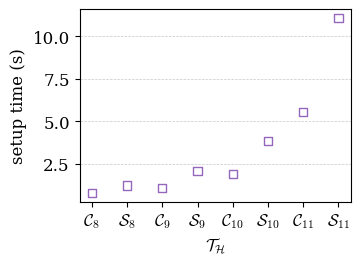

In [13]:
fig, ax = plt.subplots(figsize=(3.5, 2.5))
ax.scatter(
    range(len(coarse_solver_setup_times)),
    coarse_solver_setup_times.values / 1000,
    marker=markers["BatchCUDSS"],
    edgecolors=solver_colors["BatchCUDSS"],
    facecolors="none",
)
ax.set_xticks(range(len(coarse_solver_setup_times.index)))
ax.set_xticklabels([f"${format_mesh(ms)}$" for ms in coarse_solver_setup_times.index])
ax.yaxis.grid(True, linestyle="--", linewidth=0.5, alpha=0.7)
ax.set_ylabel("setup time (s)")
ax.set_xlabel("$\\mathcal{T}_\\mathcal{H}$")
fig.savefig("../docs/thesis-media/coarse_solver_setup_times.svg", bbox_inches="tight")